# Energy Demand Forecasting — Data Processing

**Project**: Flounder Energy Trading — Energy Demand Forecasting using ML & TiDE
**Goal**: combine New Zealand electricity demand with weather data into a clean dataset ready for time-series modelling.

Data sources (from the links in the project brief PDF):
- **Electricity demand**: New Zealand Electricity Market Information platform EMI — the `W_GD_C` (Grid Demand) report, downloaded by **Zone** at the half-hourly **Trading Period** resolution.
- **Weather**: [Open-Meteo](https://open-meteo.com/) historical archive API (free, no key).

This notebook covers: fetch → clean → timezone alignment → merge → calendar features → EDA → save the processed dataset.
Raw downloads are cached to `data/raw/`, so re-running does not re-download.

## 0. Setup & Config

In [1]:
import io
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

# `holidays` is optional: if it's not installed in the active kernel, the
# notebook still runs and the holiday feature is simply skipped (see section 5).
try:
    import holidays
    HAS_HOLIDAYS = True
except ModuleNotFoundError:
    holidays = None
    HAS_HOLIDAYS = False
    warnings.warn("`holidays` not installed -> holiday feature will be skipped. "
                  "Install it for accurate features:  pip install holidays")

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
%matplotlib inline

print("pandas", pd.__version__, "| numpy", np.__version__, "| holidays available:", HAS_HOLIDAYS)

pandas 3.0.2 | numpy 2.4.3 | holidays available: True


In [2]:
# ---- Configuration -------------------------------------------------------
# Date range for the historical training data (inclusive).
START = pd.Timestamp("2019-01-01")
END   = pd.Timestamp("2026-05-31")

# Target time resolution: "30min" keeps the native trading-period granularity
# (weather is interpolated to 30 min); "1h" aggregates demand to hourly.
TARGET_FREQ = "30min"

# NZ EMI demand zones -> a representative population-weighted weather location.
# (lat, lon) are configurable; refine later with multi-point weighting if needed.
ZONES = {
    "UNI": {"name": "Upper North Island",   "lat": -36.85, "lon": 174.76},  # Auckland
    "CNI": {"name": "Central North Island", "lat": -37.79, "lon": 175.28},  # Hamilton
    "LNI": {"name": "Lower North Island",   "lat": -41.29, "lon": 174.78},  # Wellington
    "USI": {"name": "Upper South Island",   "lat": -43.53, "lon": 172.63},  # Christchurch
    "LSI": {"name": "Lower South Island",   "lat": -45.87, "lon": 170.50},  # Dunedin
}

# Weather drivers to pull from Open-Meteo (hourly).
WEATHER_VARS = [
    "temperature_2m", "relative_humidity_2m", "dew_point_2m",
    "apparent_temperature", "precipitation", "cloud_cover",
    "wind_speed_10m", "shortwave_radiation", "surface_pressure",
]

TZ = "Pacific/Auckland"               # NZ local time (handles NZST/NZDT)
HEADERS = {"User-Agent": "Mozilla/5.0 (data-science-project)"}

# ---- Paths ---------------------------------------------------------------
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW  = ROOT / "data" / "raw"
PROC = ROOT / "data" / "processed"
RAW.mkdir(parents=True, exist_ok=True)
PROC.mkdir(parents=True, exist_ok=True)
print("ROOT:", ROOT)
print(f"Range: {START.date()} -> {END.date()} | target freq: {TARGET_FREQ}")

ROOT: C:\Users\Administrator\Desktop\energy
Range: 2019-01-01 -> 2026-05-31 | target freq: 30min


## 1. Fetch electricity demand (EMI Grid Demand)

The EMI `W_GD_C` report exposes a CSV download endpoint. We download it **per year** and cache to `data/raw/demand_<year>.csv`.
The returned CSV has a few metadata lines at the top; the real header starts at the `Period start` line.

In [3]:
EMI_CSV = "https://www.emi.ea.govt.nz/Wholesale/Download/DataReport/CSV/W_GD_C"

def _emi_request(date_from: str, date_to: str) -> pd.DataFrame:
    """Download one EMI demand CSV (RegionType=ZONE, half-hourly trading periods)."""
    params = dict(DateFrom=date_from, DateTo=date_to,
                  RegionType="ZONE", Show="Gwh", TimeScale="TP")
    r = requests.get(EMI_CSV, params=params, headers=HEADERS, timeout=180)
    r.raise_for_status()
    txt = r.text
    idx = txt.find("Period start")          # skip the metadata preamble
    if idx == -1:
        raise ValueError("Unexpected EMI response (no data header found)")
    return pd.read_csv(io.StringIO(txt[idx:]))

def fetch_demand(start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    frames = []
    for year in range(start.year, end.year + 1):
        cache = RAW / f"demand_{year}.csv"
        if cache.exists():
            df = pd.read_csv(cache)
        else:
            d_from = max(start, pd.Timestamp(year, 1, 1)).strftime("%Y%m%d")
            d_to   = min(end,   pd.Timestamp(year, 12, 31)).strftime("%Y%m%d")
            print(f"  downloading demand {d_from}..{d_to} ...")
            df = _emi_request(d_from, d_to)
            df.to_csv(cache, index=False)
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

demand_raw = fetch_demand(START, END)
print("raw demand rows:", len(demand_raw))
demand_raw.head()

raw demand rows: 649930


,Period start,Period end,Region ID,Region,Demand (GWh),Demand ($)
0,01/01/2019 00:00:00,01/01/2019 00:30:00,UNI,Upper North Island,0.467,88034.65
1,01/01/2019 00:00:00,01/01/2019 00:30:00,CNI,Central North Island,0.369,66372.35
2,01/01/2019 00:00:00,01/01/2019 00:30:00,LNI,Lower North Island,0.210,38208.24
3,01/01/2019 00:00:00,01/01/2019 00:30:00,USI,Upper South Island,0.277,53394.53
4,01/01/2019 00:00:00,01/01/2019 00:30:00,LSI,Lower South Island,0.487,93247.41


### 1.1 Tidy table + timezone handling

Convert the local trading-period time `Period start` (New Zealand wall-clock) to **UTC**. A single UTC timeline avoids the duplicate/missing-hour problems on daylight-saving transition days (46 / 50 trading periods). We localize **per zone** and set the DST `ambiguous` flag explicitly: on the autumn fall-back, the *first* occurrence of the repeated wall-clock hour is daylight time, the repeat is standard time.

In [4]:
demand = demand_raw.rename(columns={
    "Region ID": "zone", "Region": "zone_name",
    "Demand (GWh)": "demand_gwh", "Demand ($)": "demand_nzd",
})
demand["period_start_local"] = pd.to_datetime(
    demand["Period start"], format="%d/%m/%Y %H:%M:%S")

def _localize_to_utc(g: pd.DataFrame) -> pd.DataFrame:
    """Localize a single zone's chronological series to UTC (DST-safe).

    On the autumn fall-back day the wall-clock hour repeats (e.g. 02:00-02:59
    occurs twice). `ambiguous="infer"` is unreliable for half-hourly data, so we
    set the flag explicitly: the *first* occurrence of a repeated timestamp is
    still daylight time (True), the repeat is standard time (False).
    """
    local_naive = pd.DatetimeIndex(g["period_start_local"].values)
    ambiguous = ~local_naive.duplicated(keep="first")   # True=DST for 1st occurrence
    idx_utc = local_naive.tz_localize(TZ, ambiguous=ambiguous, nonexistent="shift_forward")
    g = g.copy()
    g["timestamp_utc"] = idx_utc.tz_convert("UTC")
    return g

# Iterate the groups explicitly instead of groupby().apply(): group iteration
# always keeps the grouping column ('zone') on every pandas version, whereas
# apply() excludes it by default from pandas 3.0 (the include_groups change),
# which previously dropped 'zone' and raised KeyError.
demand = pd.concat(
    [_localize_to_utc(g) for _, g in demand.groupby("zone", sort=False)],
    ignore_index=True)
demand = demand[["timestamp_utc", "zone", "zone_name", "demand_gwh", "demand_nzd"]]
demand = demand.sort_values(["zone", "timestamp_utc"]).reset_index(drop=True)
print("zones:", demand["zone"].unique().tolist())
print("span :", demand["timestamp_utc"].min(), "->", demand["timestamp_utc"].max())
demand.head()

zones: ['CNI', 'LNI', 'LSI', 'UNI', 'USI']
span : 2018-12-31 11:00:00+00:00 -> 2026-05-31 11:30:00+00:00


,timestamp_utc,zone,zone_name,demand_gwh,demand_nzd
0,2018-12-31 11:00:00+00:00,CNI,Central North Island,0.369,66372.35
1,2018-12-31 11:30:00+00:00,CNI,Central North Island,0.355,56990.32
2,2018-12-31 12:00:00+00:00,CNI,Central North Island,0.353,63283.79
3,2018-12-31 12:30:00+00:00,CNI,Central North Island,0.345,55868.37
4,2018-12-31 13:00:00+00:00,CNI,Central North Island,0.334,50290.83


## 2. Fetch weather (Open-Meteo historical archive)

For each zone's representative point, pull hourly historical weather and cache to `data/raw/weather_<zone>.csv`.
Requests use `timezone=UTC` so the weather timeline matches demand.

In [5]:
import time

ARCHIVE = "https://archive-api.open-meteo.com/v1/archive"

def fetch_weather(zone: str, lat: float, lon: float,
                  start: pd.Timestamp, end: pd.Timestamp, max_retries: int = 6) -> pd.DataFrame:
    cache = RAW / f"weather_{zone}.csv"
    if not cache.exists():
        print(f"  downloading weather {zone} ({lat},{lon}) ...")
        params = {
            "latitude": lat, "longitude": lon,
            "start_date": start.strftime("%Y-%m-%d"),
            "end_date": end.strftime("%Y-%m-%d"),
            "hourly": ",".join(WEATHER_VARS), "timezone": "UTC",
        }
        for attempt in range(max_retries):
            r = requests.get(ARCHIVE, params=params, headers=HEADERS, timeout=180)
            if r.status_code == 200:
                break
            if r.status_code == 429:                 # rate limited: back off and retry
                wait = 15 * (attempt + 1)
                print(f"    429 rate limited; retrying in {wait}s ...")
                time.sleep(wait)
                continue
            r.raise_for_status()
        else:
            raise RuntimeError(f"weather download for {zone} failed after {max_retries} retries")
        w = pd.DataFrame(r.json()["hourly"]).rename(columns={"time": "timestamp_utc"})
        w["zone"] = zone
        w.to_csv(cache, index=False)
        time.sleep(2)                                # be gentle between live requests
    w = pd.read_csv(cache)
    w["timestamp_utc"] = pd.to_datetime(w["timestamp_utc"], utc=True)
    return w

weather = pd.concat(
    [fetch_weather(z, c["lat"], c["lon"], START, END) for z, c in ZONES.items()],
    ignore_index=True)
print("weather rows:", len(weather), "| zones:", weather["zone"].unique().tolist())
weather.head()

weather rows: 324960 | zones: ['UNI', 'CNI', 'LNI', 'USI', 'LSI']


,timestamp_utc,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,shortwave_radiation,surface_pressure,zone
0,2019-01-01 00:00:00+00:00,22.0,74,17.0,22.5,0.2,100,18.9,701.0,1010.2,UNI
1,2019-01-01 01:00:00+00:00,22.6,71,17.0,23.7,0.1,100,19.1,828.0,1010.1,UNI
2,2019-01-01 02:00:00+00:00,22.5,73,17.3,23.5,0.1,97,19.5,814.0,1009.6,UNI
3,2019-01-01 03:00:00+00:00,22.5,73,17.3,23.1,0.0,100,20.7,772.0,1009.4,UNI
4,2019-01-01 04:00:00+00:00,21.8,75,17.1,21.1,0.1,100,22.2,536.0,1009.2,UNI


## 3. Data-quality checks (Validation)

Check for duplicates, missing trading periods and outliers. At half-hourly frequency each zone should have roughly `365*48 = 17520` records per year (±a little on DST days).

In [6]:
def quality_report(df, value_cols, group="zone"):
    rows = []
    for z, g in df.groupby(group):
        rec = {"zone": z, "rows": len(g),
               "dup_ts": int(g.duplicated(["timestamp_utc"]).sum()),
               "start": g["timestamp_utc"].min(), "end": g["timestamp_utc"].max()}
        for c in value_cols:
            rec[f"{c}_na"] = int(g[c].isna().sum())
        rows.append(rec)
    return pd.DataFrame(rows)

print("=== DEMAND ===")
display(quality_report(demand, ["demand_gwh"]))
print("=== WEATHER ===")
display(quality_report(weather, ["temperature_2m", "wind_speed_10m"]))

# negative / zero demand sanity
neg = (demand["demand_gwh"] <= 0).sum()
print(f"\nnon-positive demand rows: {neg}")
print("demand_gwh describe:\n", demand["demand_gwh"].describe())

=== DEMAND ===


,zone,rows,dup_ts,start,end,demand_gwh_na
0,CNI,129986,0,2018-12-31 11:00:00+00:00,2026-05-31 11:30:00+00:00,70
1,LNI,129986,0,2018-12-31 11:00:00+00:00,2026-05-31 11:30:00+00:00,79
2,LSI,129986,0,2018-12-31 11:00:00+00:00,2026-05-31 11:30:00+00:00,101
3,UNI,129986,0,2018-12-31 11:00:00+00:00,2026-05-31 11:30:00+00:00,87
4,USI,129986,0,2018-12-31 11:00:00+00:00,2026-05-31 11:30:00+00:00,93


=== WEATHER ===


,zone,rows,dup_ts,start,end,temperature_2m_na,wind_speed_10m_na
0,CNI,64992,0,2019-01-01 00:00:00+00:00,2026-05-31 23:00:00+00:00,0,0
1,LNI,64992,0,2019-01-01 00:00:00+00:00,2026-05-31 23:00:00+00:00,0,0
2,LSI,64992,0,2019-01-01 00:00:00+00:00,2026-05-31 23:00:00+00:00,0,0
3,UNI,64992,0,2019-01-01 00:00:00+00:00,2026-05-31 23:00:00+00:00,0,0
4,USI,64992,0,2019-01-01 00:00:00+00:00,2026-05-31 23:00:00+00:00,0,0



non-positive demand rows: 0
demand_gwh describe:
 count    649500.000000
mean          0.471781
std           0.154883
min           0.174000
25%           0.356000
50%           0.466000
75%           0.550000
max           1.209000
Name: demand_gwh, dtype: float64


## 4. Align & Merge

Demand is half-hourly, weather is hourly. With the default `TARGET_FREQ="30min"`, weather is **interpolated** in time onto the half-hourly demand timestamps. If set to `"1h"`, demand is **summed** to hourly (GWh is energy per trading period, hence summed) and weather kept at its native hourly values. The result is a **tidy panel** (long format): one row per (timestamp, zone).

In [7]:
def build_panel(demand, weather, freq):
    out = []
    wcols = WEATHER_VARS
    for z in ZONES:
        d = (demand[demand.zone == z]
             .set_index("timestamp_utc").sort_index())
        w = (weather[weather.zone == z]
             .set_index("timestamp_utc").sort_index()[wcols])

        if freq == "1h":
            d_res = d[["demand_gwh", "demand_nzd"]].resample("1h").sum(min_count=1)
            d_meta = d[["zone", "zone_name"]].resample("1h").first()
            d_res = d_res.join(d_meta)
            m = d_res.join(w)                       # weather already hourly
        else:  # 30min: interpolate weather onto the demand index
            w30 = (w.reindex(w.index.union(d.index))
                     .interpolate(method="time")
                     .reindex(d.index))
            m = d.join(w30)
        out.append(m.reset_index())
    panel = pd.concat(out, ignore_index=True)
    return panel.sort_values(["zone", "timestamp_utc"]).reset_index(drop=True)

panel = build_panel(demand, weather, TARGET_FREQ)
panel["zone_name"] = panel["zone"].map(lambda z: ZONES[z]["name"])
print("panel shape:", panel.shape)
print("missing per column:\n", panel[WEATHER_VARS + ["demand_gwh"]].isna().sum())
panel.head()

panel shape: (649930, 14)
missing per column:
 temperature_2m          130
relative_humidity_2m    130
dew_point_2m            130
apparent_temperature    130
precipitation           130
cloud_cover             130
wind_speed_10m          130
shortwave_radiation     130
surface_pressure        130
demand_gwh              430
dtype: int64


,timestamp_utc,zone,zone_name,demand_gwh,demand_nzd,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,shortwave_radiation,surface_pressure
0,2018-12-31 11:00:00+00:00,CNI,Central North Island,0.369,66372.35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-12-31 11:30:00+00:00,CNI,Central North Island,0.355,56990.32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-12-31 12:00:00+00:00,CNI,Central North Island,0.353,63283.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-12-31 12:30:00+00:00,CNI,Central North Island,0.345,55868.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-12-31 13:00:00+00:00,CNI,Central North Island,0.334,50290.83,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Calendar Features

Demand has strong daily / weekly / seasonal structure. Derive calendar features from **New Zealand local time** and add a New Zealand public-holiday flag (holiday load patterns differ from weekdays). Periodic variables are sin/cos encoded.

In [8]:
local = panel["timestamp_utc"].dt.tz_convert(TZ)
panel["hour"]       = local.dt.hour
panel["minute"]     = local.dt.minute
panel["dayofweek"]  = local.dt.dayofweek            # 0=Mon
panel["month"]      = local.dt.month
panel["dayofyear"]  = local.dt.dayofyear
panel["is_weekend"] = panel["dayofweek"].isin([5, 6])

# NZ public holidays (national). Skipped gracefully if `holidays` isn't installed.
if HAS_HOLIDAYS:
    nz_holidays = holidays.NewZealand(years=range(START.year, END.year + 1))
    panel["is_holiday"] = local.dt.date.map(lambda d: d in nz_holidays)
else:
    panel["is_holiday"] = False
    warnings.warn("`holidays` unavailable -> is_holiday set to False for all rows.")

# cyclical encodings
tod = panel["hour"] + panel["minute"] / 60.0        # time-of-day in hours
panel["tod_sin"]   = np.sin(2 * np.pi * tod / 24)
panel["tod_cos"]   = np.cos(2 * np.pi * tod / 24)
panel["dow_sin"]   = np.sin(2 * np.pi * panel["dayofweek"] / 7)
panel["dow_cos"]   = np.cos(2 * np.pi * panel["dayofweek"] / 7)
panel["doy_sin"]   = np.sin(2 * np.pi * panel["dayofyear"] / 365.25)
panel["doy_cos"]   = np.cos(2 * np.pi * panel["dayofyear"] / 365.25)

print("holiday rows:", int(panel["is_holiday"].sum()))
panel[["timestamp_utc", "zone", "demand_gwh", "hour", "dayofweek",
       "is_weekend", "is_holiday", "temperature_2m"]].head()

holiday rows: 22560


,timestamp_utc,zone,demand_gwh,hour,dayofweek,is_weekend,is_holiday,temperature_2m
0,2018-12-31 11:00:00+00:00,CNI,0.369,0,1,False,True,NaN
1,2018-12-31 11:30:00+00:00,CNI,0.355,0,1,False,True,NaN
2,2018-12-31 12:00:00+00:00,CNI,0.353,1,1,False,True,NaN
3,2018-12-31 12:30:00+00:00,CNI,0.345,1,1,False,True,NaN
4,2018-12-31 13:00:00+00:00,CNI,0.334,2,1,False,True,NaN


## 6. Exploratory Analysis (EDA)

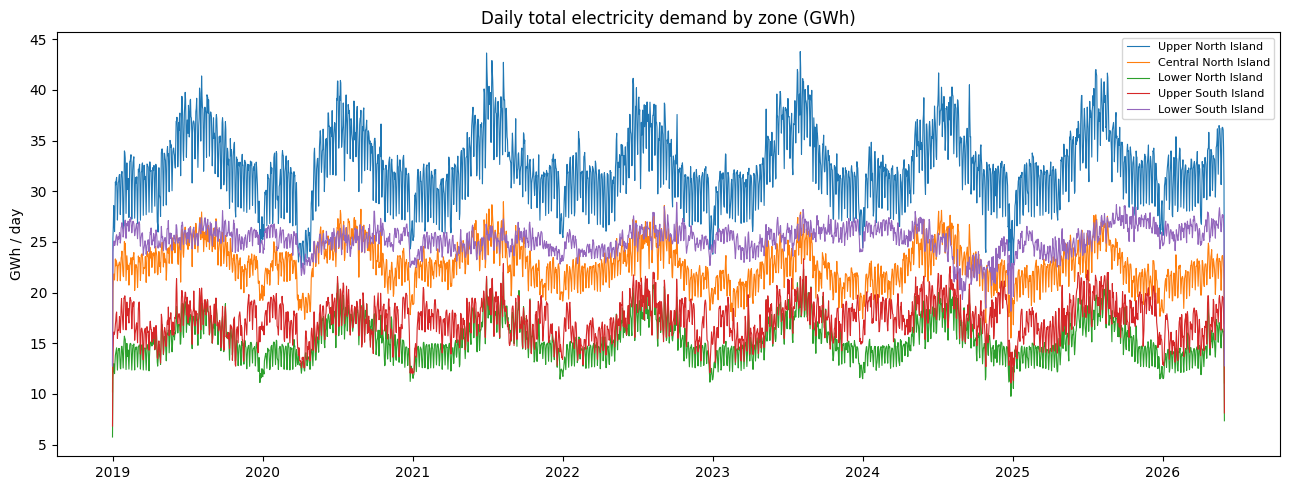

In [9]:
# 6.1 Daily total demand per zone (aggregated daily, to see trend/seasonality)
fig, ax = plt.subplots(figsize=(13, 5))
for z in ZONES:
    s = (panel[panel.zone == z]
         .set_index("timestamp_utc")["demand_gwh"].resample("1D").sum())
    ax.plot(s.index, s.values, label=ZONES[z]["name"], lw=0.8)
ax.set_title("Daily total electricity demand by zone (GWh)")
ax.set_ylabel("GWh / day"); ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

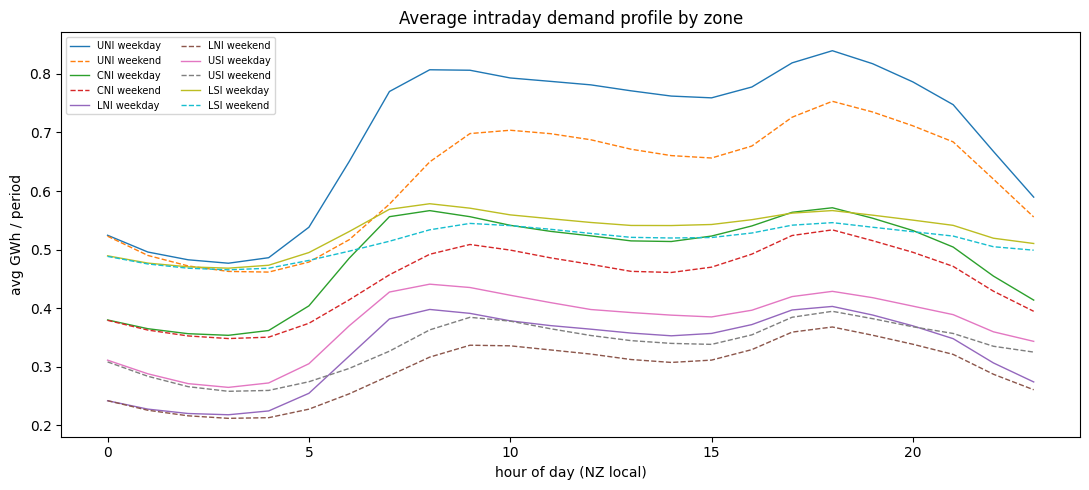

In [10]:
# 6.2 Average intraday load profile (weekday vs weekend)
fig, ax = plt.subplots(figsize=(11, 5))
for z in ZONES:
    g = panel[panel.zone == z]
    for wk, ls in [(False, "-"), (True, "--")]:
        prof = g[g.is_weekend == wk].groupby("hour")["demand_gwh"].mean()
        ax.plot(prof.index, prof.values, ls,
                label=f"{z} {'weekend' if wk else 'weekday'}", lw=1)
ax.set_title("Average intraday demand profile by zone")
ax.set_xlabel("hour of day (NZ local)"); ax.set_ylabel("avg GWh / period")
ax.legend(ncol=2, fontsize=7); plt.tight_layout(); plt.show()

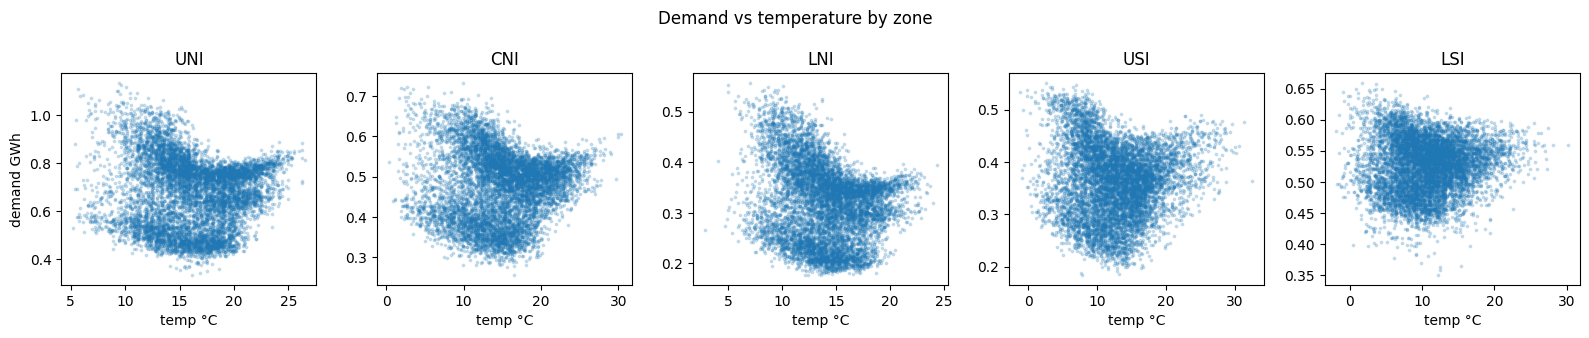

In [11]:
# 6.3 Demand vs temperature (key driver: heating/cooling 'U' shape)
fig, axes = plt.subplots(1, len(ZONES), figsize=(16, 3.4), sharey=False)
for ax, z in zip(axes, ZONES):
    g = panel[panel.zone == z].sample(min(8000, (panel.zone == z).sum()), random_state=0)
    ax.scatter(g["temperature_2m"], g["demand_gwh"], s=3, alpha=0.2)
    ax.set_title(z); ax.set_xlabel("temp °C")
axes[0].set_ylabel("demand GWh")
fig.suptitle("Demand vs temperature by zone")
plt.tight_layout(); plt.show()

## 7. Save the processed dataset

Save as **Parquet** (preserves dtypes and timezone) for the modelling notebooks, plus a small CSV sample for quick inspection.

In [12]:
out_parquet = PROC / "demand_weather_panel.parquet"
panel.to_parquet(out_parquet, index=False)
panel.head(2000).to_csv(PROC / "demand_weather_sample.csv", index=False)

print("saved:", out_parquet)
print("shape:", panel.shape)
print("columns:", list(panel.columns))
print("\nper-zone rows:\n", panel.groupby("zone_name").size())
print("\ntime span:", panel["timestamp_utc"].min(), "->", panel["timestamp_utc"].max())

saved: C:\Users\Administrator\Desktop\energy\data\processed\demand_weather_panel.parquet
shape: (649930, 27)
columns: ['timestamp_utc', 'zone', 'zone_name', 'demand_gwh', 'demand_nzd', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature', 'precipitation', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation', 'surface_pressure', 'hour', 'minute', 'dayofweek', 'month', 'dayofyear', 'is_weekend', 'is_holiday', 'tod_sin', 'tod_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos']

per-zone rows:
 zone_name
Central North Island    129986
Lower North Island      129986
Lower South Island      129986
Upper North Island      129986
Upper South Island      129986
dtype: int64

time span: 2018-12-31 11:00:00+00:00 -> 2026-05-31 11:30:00+00:00


---
### Next steps
- **Modelling notebook**: build baselines on `demand_weather_panel.parquet` (e.g. per-zone seasonal-naive / gradient boosting), then implement **TiDE** (paper [arXiv:2304.08424](https://arxiv.org/abs/2304.08424)) for long-term forecasting.
- **Weather-scenario forecasting**: drive the model with Open-Meteo forecast / scenario weather inputs to forecast demand under different weather (the project's target output).
- **Optional extensions**: lag features, rolling statistics, holiday lead/lag effects, multi-point weighted weather, probabilistic prediction intervals.